In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
FIT = FitSpectrum()
DP = DP()

dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0430_all_test.fits')
# dps_df = dps_df[dps_df['BPT_1COMP']==16].copy()
ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list(), subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 37.30 seconds.
Total number of spectra: 57271


In [4]:
test_idx = dps_df[dps_df['TARGETID'] == 39627758267011989].index[0]
# test_idx = np.random.randint(0, len(ALL_SPECTRA.df))
test_id = ALL_SPECTRA.df.iloc[test_idx]["TARGETID"]
# print(f'TARGETID: {test_id}')
lam = desi_wavelength / (1+ALL_SPECTRA.df.iloc[test_idx]['Z'])

In [5]:
test_df = ALL_SPECTRA.df.iloc[test_idx]
print(test_df)

TARGETID    39627758267011989
RA                 222.931782
DEC                 -1.284414
Z                     0.18078
SPECTYPE               GALAXY
LOGM                10.779719
LOGSFR               1.651624
Name: 14092, dtype: object


In [6]:
params = []
models = []
chisqs = []
for i in range(4):
    param, (combine_lam, combine_flux, combine_sigma, combine_model), slice_indices, _, _ = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=None, w_dz=False, n_components=i+1)
    model = np.sum([
        model_vel(lam, gaussian_parms=param['gaussian_params'][j]) for j in range(len(param['gaussian_params']))
    ], axis=0)
    chisq = np.sum((combine_flux - combine_model)**2 / combine_sigma**2)
    params.append(param)
    models.append(model)
    chisqs.append(chisq)

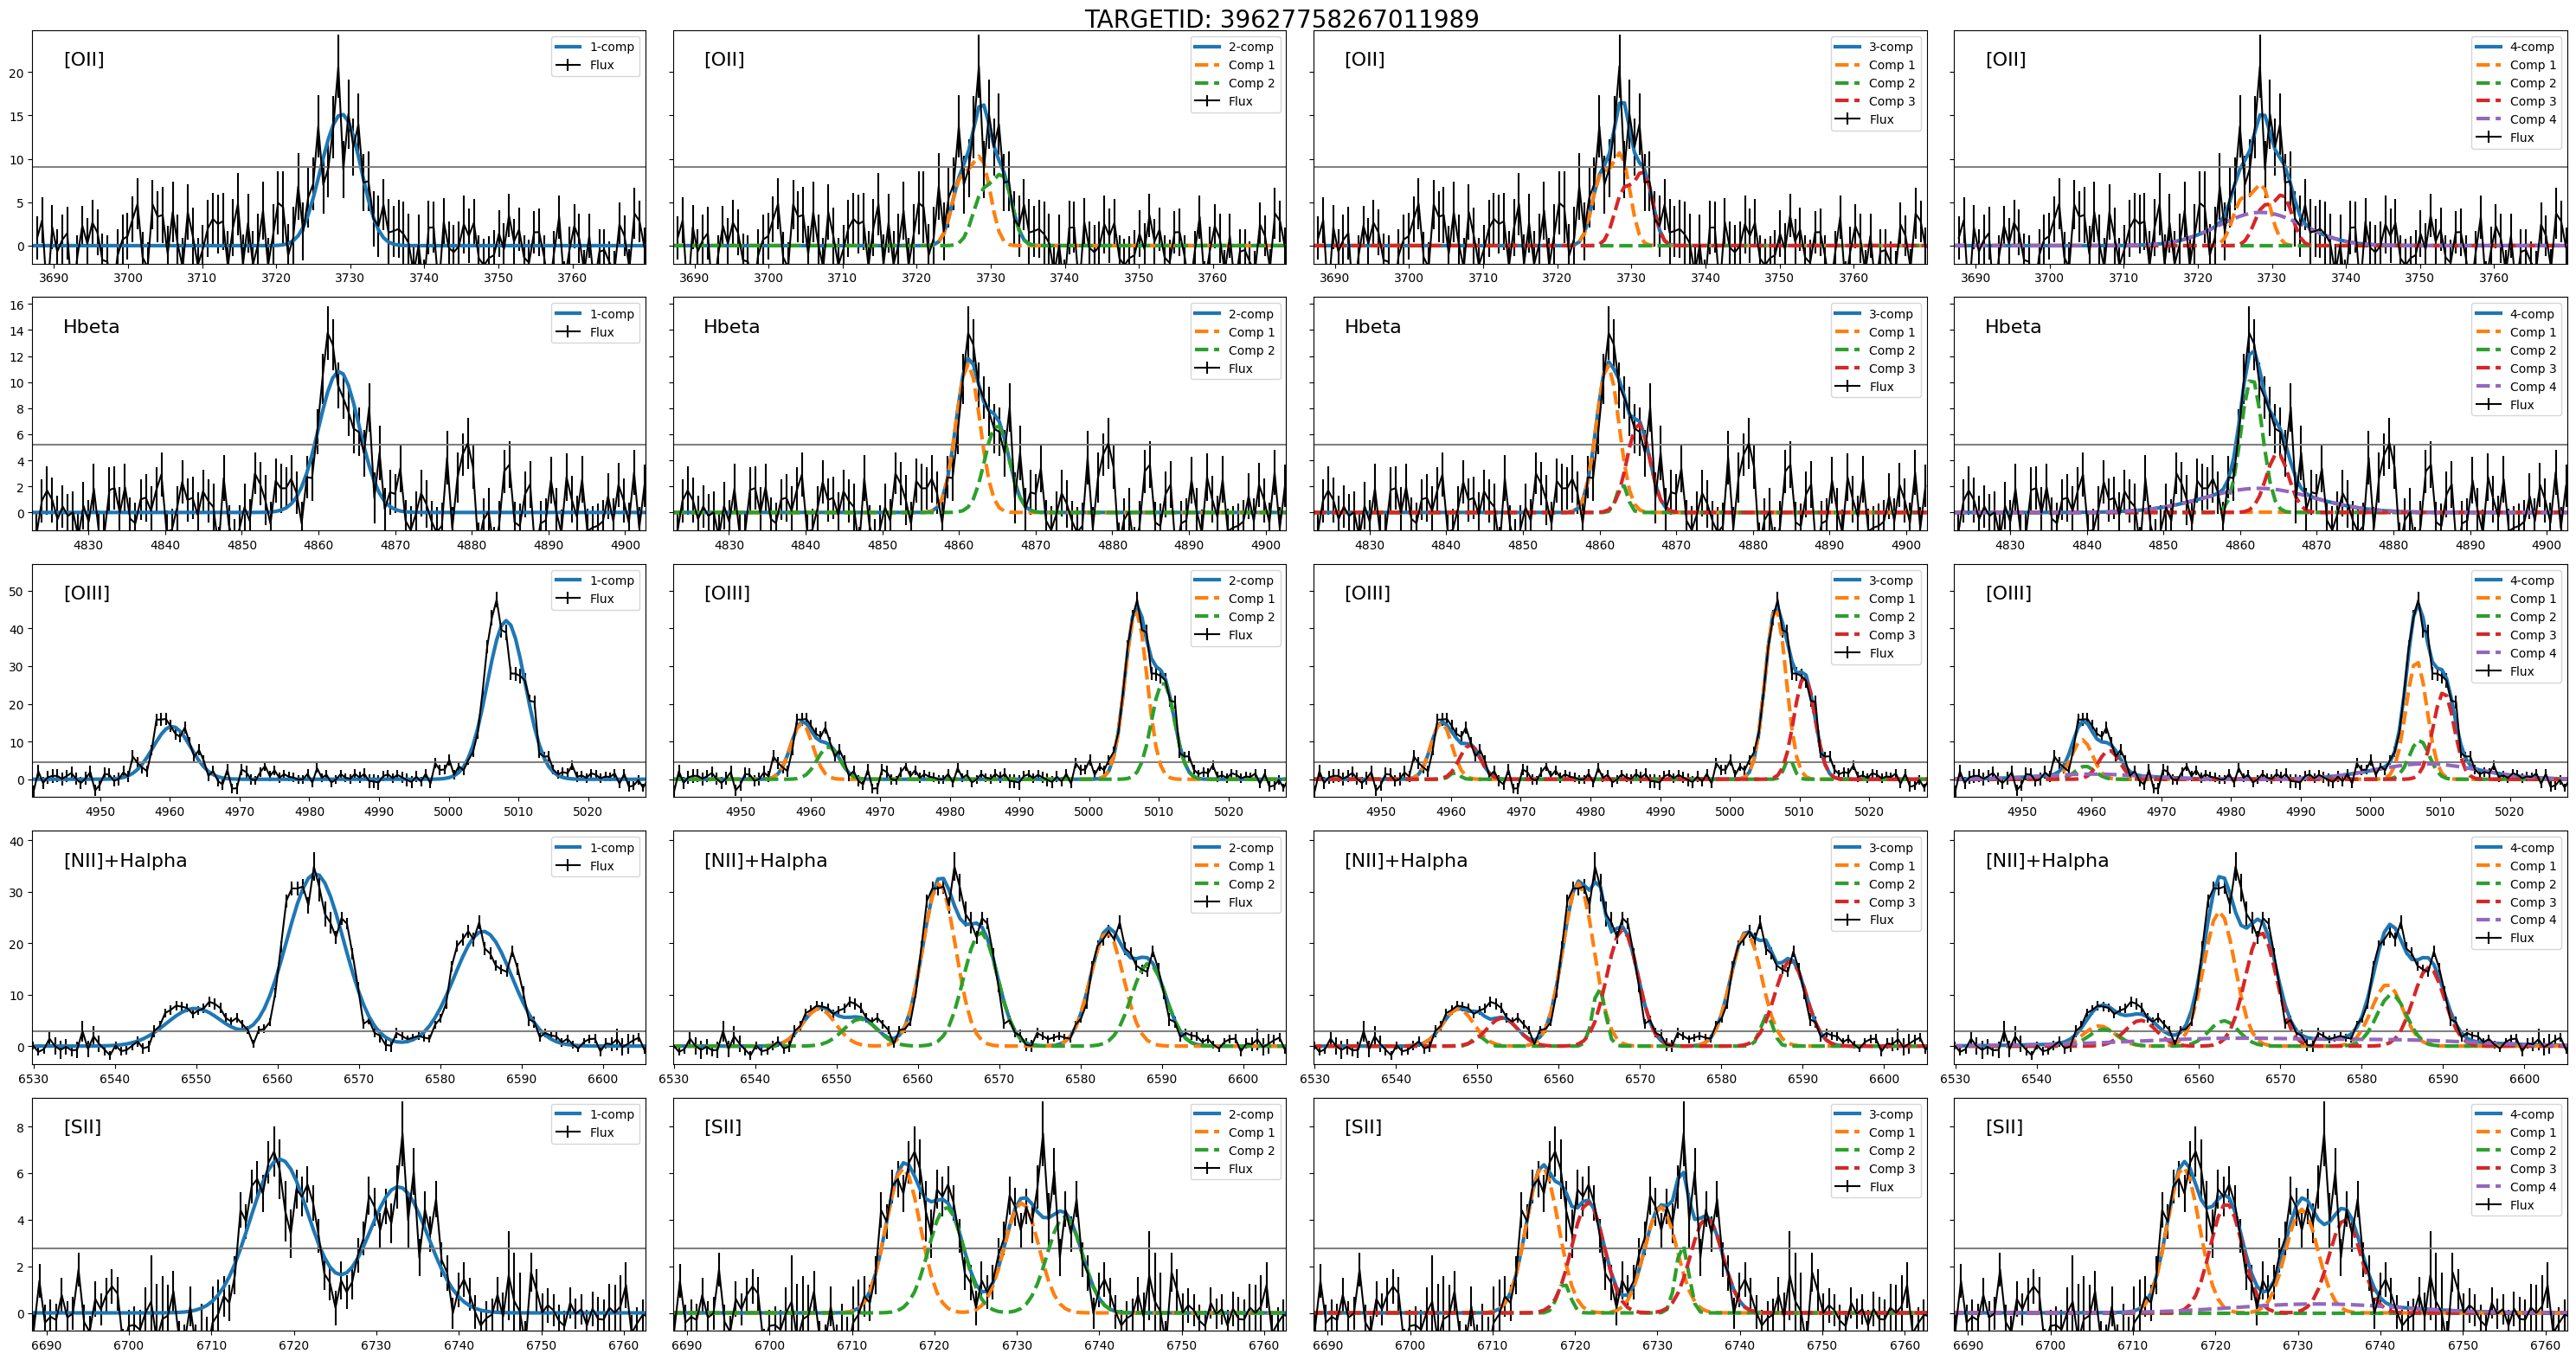

In [7]:
plot_ranges = [
    (OII_rest[0]-40, OII_rest[1]+40),
    (Hbeta_rest[0]-40, Hbeta_rest[0]+40),
    (OIII_rest[0]-20, OIII_rest[1]+20),
    (NII_rest[0]-20, NII_rest[1]+20),
    (SII_rest[0]-30, SII_rest[1]+30)
]


fig, axes = plt.subplots(len(plot_ranges), len(models), figsize=(6*len(plot_ranges), 4*len(models)), sharey='row')
plt.subplots_adjust(wspace=0., hspace=0.)

lam_split  = np.split(combine_lam, slice_indices)
flux_split = np.split(combine_flux, slice_indices)
sigma_split = np.split(combine_sigma, slice_indices)


snr = 3




for i, (model, param) in enumerate(zip(models, params)):
    for k, ranges in enumerate(plot_ranges):
        ax = axes[k, i]
        ax.errorbar(lam_split[k], flux_split[k], yerr=sigma_split[k], label='Flux', color='k')
        # ax.step(lam_split[k], flux_split[k], label='Flux', color='k')
        ax.plot(lam, model, label=f'{i+1}-comp', lw=3)
        ax.axhline(snr*np.mean(sigma_split[k]), color='gray')

        if i !=0:
            for j in range(len(param['components'])):
                comp = np.sum([
                    model_vel(lam, gaussian_parms=param['components'][j]['gaussian_params'][k]) for k in range(len(param['components'][j]['gaussian_params']))
                ], axis=0)
                ax.plot(lam, comp, label=f'Comp {j+1}', lw=3, ls='--')

        ax.set_xlim(ranges)
        ax.set_ylim(bottom=-np.max(flux_split[k])*0.1, top=np.max(flux_split[k])*1.2)
        # ax.set_ylim(bottom=-1*np.mean(sigma_split[k]), top=15*np.mean(sigma_split[k]))
        ax.legend()

for k in range(len(models)):
    axes[0, k].text(0.05, 0.85, '[OII]', transform=axes[0, k].transAxes, fontsize=16)
    axes[1, k].text(0.05, 0.85, 'Hbeta', transform=axes[1, k].transAxes, fontsize=16)
    axes[2, k].text(0.05, 0.85, '[OIII]', transform=axes[2, k].transAxes, fontsize=16)
    axes[3, k].text(0.05, 0.85, '[NII]+Halpha', transform=axes[3, k].transAxes, fontsize=16)
    axes[4, k].text(0.05, 0.85, '[SII]', transform=axes[4, k].transAxes, fontsize=16)
fig.suptitle(f'TARGETID: {test_id}', fontsize=20)
plt.tight_layout()
plt.show()

Best model: 2-Component

Delta BIC relative to best model:
1-Component: Delta BIC = 418.0231
2-Component: Delta BIC = 0.0000
3-Component: Delta BIC = 25.5566
4-Component: Delta BIC = 6.9264


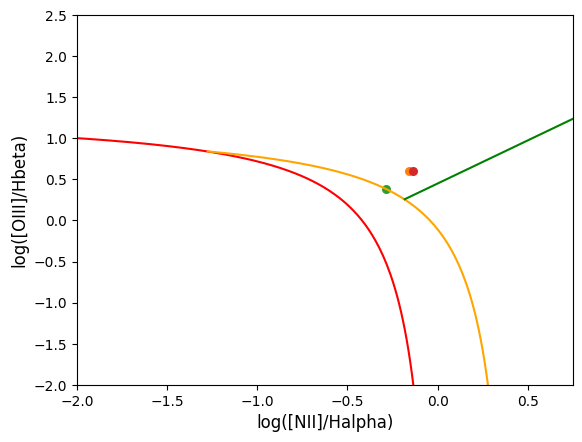

In [8]:
# Calculate BIC for each model

n_data = len(combine_lam)
ks = [9, 18, 27, 36, 45, 54]
bics = []
for i in range(len(models)):
    bics.append(ks[i] * np.log(n_data) + chisqs[i])


# Find best model (lowest BIC)
bic_values = np.array(bics)
best_model = np.argmin(bic_values) + 1
delta_bic = bic_values - np.min(bic_values)

print(f"Best model: {best_model}-Component")
print("\nDelta BIC relative to best model:")

for i, dbic in enumerate(delta_bic, start=1):
    print(f"{i}-Component: Delta BIC = {dbic:.4f}")

best_model=3

Hbeta = np.array(params[best_model-1]['amps'][1])
OIII = np.array(params[best_model-1]['amps'][2][1::2])
Halpha = np.array(params[best_model-1]['amps'][3][2*best_model:])
NII = np.array(params[best_model-1]['amps'][3][:2*best_model][1::2])


logoiii_hb = np.log10(OIII / Hbeta)
lognii_ha = np.log10(NII / Halpha)
if best_model != 1:
    for i in range(len(lognii_ha)):
        plt.scatter(lognii_ha[i], logoiii_hb[i], c=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'][i], s=30)
else:
    plt.scatter(lognii_ha, logoiii_hb, c='C0', s=30)

x = np.linspace(-4, 1, 500)
sf_boundary = 0.61/(x-0.05) + 1.30
comp_boundary = 0.61/(x-0.47) + 1.19
liner_boundary = 1.05*x + 0.45
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
plt.xlim((-2, 0.75))
plt.ylim((-2, 2.5))
plt.xlabel('log([NII]/Halpha)', fontsize=12)
plt.ylabel('log([OIII]/Hbeta)', fontsize=12)
plt.show()

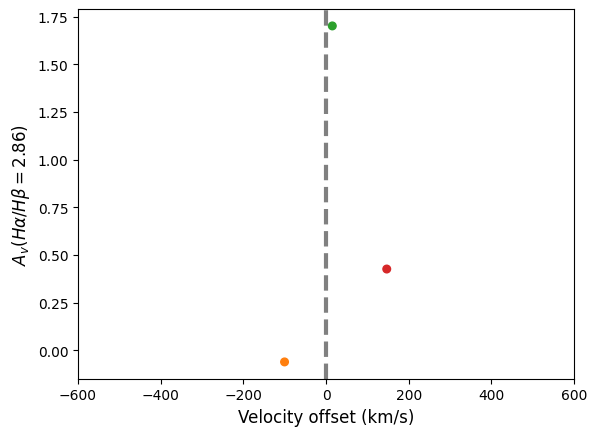

In [9]:
plt.scatter(params[best_model-1]['dv'], reddening(Halpha, Hbeta), c=['C1', 'C2', 'C3', 'C4', 'C5', 'C6'][0:best_model], s=30)
plt.axvline(0, lw=3, ls='--', color='gray')
plt.xlim((-600, 600))
# plt.ylim(bottom=0)
plt.xlabel('Velocity offset (km/s)', fontsize=12)
plt.ylabel(r'$A_{v} (H \alpha/ H \beta = 2.86)$', fontsize=12)
plt.show()

In [10]:
print(params[3]['dv'])
print(params[3]['sigma'])

(np.float64(-97.8326184511725), np.float64(-72.79503733107715), np.float64(135.2740919366349), np.float64(-14.482449888543622))
(np.float64(81.63267321164194), np.float64(76.91609778295714), np.float64(82.07392269929201), np.float64(438.93839530518255))


In [11]:
print(params[2]['dv'])
print(params[2]['sigma'])

(np.float64(-100.34412156560731), np.float64(15.191286991592307), np.float64(146.8894847996106))
(np.float64(81.94955479424236), np.float64(18.505758791440304), np.float64(82.37897809784394))


In [12]:
print(params[1]['dv'])
print(params[1]['sigma'])

(np.float64(-93.02866276203365), np.float64(139.92770484779663))
(np.float64(87.93744965100946), np.float64(90.8976485168578))


In [13]:
print(params[0]['sigma'])

158.14358357739087


In [14]:
print(params[3]['dv_err'])
print(params[3]['sigma_err'])

(np.float64(109.66006684431036), np.float64(85.81613080370533), np.float64(10.468452010546718), np.float64(42.74745714641852))
(np.float64(5.912397902294818), np.float64(35.27441029939058), np.float64(6.682721089559172), np.float64(59.03230535921825))


In [15]:
print(params[3]['amps'][2][::2])
print(params[3]['amps_err'][2][::2])

[np.float64(10.460012451613094), np.float64(3.457636539390248), np.float64(7.696075256961714), np.float64(1.3677349253100441)]
[np.float64(46.62273391957732), np.float64(48.143192955026116), np.float64(0.7305890266850537), np.float64(0.29009724457968034)]


In [16]:
print(params[3]['amps'][2][1::2])
print(params[3]['amps_err'][2][1::2])

[np.float64(31.380037354839285), np.float64(10.372909618170745), np.float64(23.088225770885142), np.float64(4.103204775930132)]
[np.float64(139.86820175873197), np.float64(144.42957886507835), np.float64(2.191767080055161), np.float64(0.8702917337390411)]


In [17]:
print(params[3]['amps'][3][:8][::2])
print(params[3]['amps_err'][3][:8][::2])

[np.float64(3.932153122786783), np.float64(3.2873500215865206), np.float64(5.013761529180626), np.float64(0.35769208243160105)]
[np.float64(22.055744660841636), np.float64(22.21624144019413), np.float64(0.3512849366530219), np.float64(0.14112547941234002)]


In [18]:
print(params[3]['amps'][3][:8][1::2])
print(params[3]['amps_err'][3][:8][1::2])

[np.float64(11.993067024499688), np.float64(10.026417565838887), np.float64(15.291972664000907), np.float64(1.090960851416383)]
[np.float64(67.27002121556698), np.float64(67.75953639259208), np.float64(1.0714190567917168), np.float64(0.430432712207637)]


In [19]:
OII3726_amp = params[best_model-1]['amps'][0][::2]
OII3729_amp = params[best_model-1]['amps'][0][1::2]
Hbeta_amp = params[best_model-1]['amps'][1]
OIII4959_amp = params[best_model-1]['amps'][2][::2]
OIII5007_amp = params[best_model-1]['amps'][2][1::2]
NII6548_amp = params[best_model-1]['amps'][3][:best_model*2][::2]
Halpha_amp = params[best_model-1]['amps'][3][best_model*2:]
NII6583_amp = params[best_model-1]['amps'][3][:best_model*2][1::2]
SII6716_amp = params[best_model-1]['amps'][4][:best_model*2]
SII6731_amp = params[best_model-1]['amps'][4][best_model*2:]

In [20]:
print(Halpha_amp)

[np.float64(31.66070328124335), np.float64(11.563266898715726), np.float64(22.68578041101156)]


In [21]:
print(np.concatenate(params[3]['components'][0]['amps']))
print(np.concatenate(params[3]['components'][0]['amps_err']))


[5.04180846e+00 6.70560525e+00 1.49962693e-36 1.04600125e+01
 3.13800374e+01 3.93215312e+00 1.19930670e+01 2.62273875e+01
 6.25613327e+00 4.44415450e+00]
[ 22.62821621  30.09552756  38.85615018  46.62273392 139.86820176
  22.05574466  67.27002122 109.74005083  24.68129068  17.46304623]


In [22]:
print(params[3]['dv'])
print(params[3]['sigma'])
print(params[3]['lam0s'])

(np.float64(-97.8326184511725), np.float64(-72.79503733107715), np.float64(135.2740919366349), np.float64(-14.482449888543622))
(np.float64(81.63267321164194), np.float64(76.91609778295714), np.float64(82.07392269929201), np.float64(438.93839530518255))
[[np.float64(3727.091748595836), np.float64(3729.875469807032), np.float64(3727.091748595836), np.float64(3729.875469807032), np.float64(3727.091748595836), np.float64(3729.875469807032), np.float64(3727.091748595836), np.float64(3729.875469807032)], [np.float64(4862.691039788272), np.float64(4862.691039788272), np.float64(4862.691039788272), np.float64(4862.691039788272)], [np.float64(4960.29494822753), np.float64(5008.239685935203), np.float64(4960.29494822753), np.float64(5008.239685935203), np.float64(4960.29494822753), np.float64(5008.239685935203), np.float64(4960.29494822753), np.float64(5008.239685935203)], [np.float64(6549.8590281116185), np.float64(6585.27854800011), np.float64(6549.8590281116185), np.float64(6585.27854800011)

In [23]:
lum_comp1 = lum(flux(np.concatenate(params[3]['components'][0]['amps']), 
                     params[3]['sigma'][0], 
                     np.concatenate(params[3]['components'][0]['lam0s']), 
                     params[3]['dv'][0]), 
                z=0.01)
print(lum_comp1)

[3.05805655e+54 4.07025296e+54 1.18672200e+18 8.44362210e+54
 2.55757069e+55 4.19132617e+54 1.28526741e+55 2.80191207e+55
 6.83996851e+54 4.86928780e+54]


In [24]:
from scipy.stats import f

F_stat_12 = ((chisqs[0] - chisqs[1]) / (ks[1]-ks[0])) / (chisqs[1] / (n_data-ks[1]))
p_value_12 = 1 - f.cdf(F_stat_12, ks[1]-ks[0], n_data-ks[1])
if p_value_12 > 0.05:
    print("1-Component")
else:
    F_stat_23 = ((chisqs[1] - chisqs[2]) / (ks[2]-ks[1])) / (chisqs[2] / (n_data-ks[2]))
    p_value_23 = 1 - f.cdf(F_stat_23, ks[2]-ks[1], n_data-ks[2])
    if p_value_23 > 0.05:
        print("2-Component")
    else:
        F_stat_34 = ((chisqs[2] - chisqs[3]) / (ks[3]-ks[2])) / (chisqs[3] / (n_data-ks[3]))
        p_value_34 = 1 - f.cdf(F_stat_34, ks[3]-ks[2], n_data-ks[3])
        if p_value_34 > 0.05:
            print("3-Component")
        else:
            print("4-Component")



4-Component
